# Quick Commerce Demand Forecasting & Inventory Optimization

#   1. Business Problem

         Corporación Favorita, one of Ecuador's largest grocery retailers, aims to improve inventory planning by understanding customer demand patterns. Accurate demand forecasting is essential to reduce stockouts, minimize overstocking, and optimize inventory across stores. This project analyzes historical sales data to identify key demand drivers and build a forecasting model that supports better inventory and business decisions.

# 2. Import Libraries 

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 3. Load Datasets

In [2]:
# Load Datasets

train = pd.read_csv(
    "/kaggle/input/notebooks/sandraezzat/favorita-grocery-sales-forecasting/train.csv",
    nrows=1000000
)

# Product Information
items = pd.read_csv("/kaggle/input/notebooks/sandraezzat/favorita-grocery-sales-forecasting/items.csv")

# Store Information
stores = pd.read_csv("/kaggle/input/notebooks/sandraezzat/favorita-grocery-sales-forecasting/stores.csv")

# Transactions
transactions = pd.read_csv("/kaggle/input/notebooks/sandraezzat/favorita-grocery-sales-forecasting/transactions.csv")

# Holidays
holidays = pd.read_csv("/kaggle/input/notebooks/sandraezzat/favorita-grocery-sales-forecasting/holidays_events.csv")

# Oil Prices
oil = pd.read_csv("/kaggle/input/notebooks/sandraezzat/favorita-grocery-sales-forecasting/oil.csv")

Convert Date Columns

In [3]:
# Convert Date Columns

train["date"] = pd.to_datetime(train["date"])
transactions["date"] = pd.to_datetime(transactions["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
oil["date"] = pd.to_datetime(oil["date"])

Check Dataset Shapes

In [4]:
# Check Dataset Shapes

datasets = {
    "Train": train,
    "Items": items,
    "Stores": stores,
    "Transactions": transactions,
    "Holidays": holidays,
    "Oil": oil
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Train: (1000000, 6)
Items: (4100, 4)
Stores: (54, 5)
Transactions: (83488, 3)
Holidays: (350, 6)
Oil: (1218, 2)


In [5]:
train.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN


In [6]:
items.head()

,item_nbr,family,class,perishable
0,96995,GROCERY I,1093,0
1,99197,GROCERY I,1067,0
2,103501,CLEANING,3008,0
3,103520,GROCERY I,1028,0
4,103665,BREAD/BAKERY,2712,1


In [7]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [8]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [9]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [10]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


# 4. Data Cleaning 

In [11]:
# Dataset Information

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name} Dataset Information")
    print(f"{'='*60}")
    print(df.info())


Train Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1000000 non-null  int64         
 1   date         1000000 non-null  datetime64[ns]
 2   store_nbr    1000000 non-null  int64         
 3   item_nbr     1000000 non-null  int64         
 4   unit_sales   1000000 non-null  float64       
 5   onpromotion  0 non-null        float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 45.8 MB
None

Items Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   item_nbr    4100 non-null   int64 
 1   family      4100 non-null   object
 2   class       4100 non-null   int64 
 3   perishable  4100 non-null   int64 
dtypes

In [12]:
# Statistical Summary

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name} Dataset Summary")
    print(f"{'='*60}")
    display(df.describe(include='all'))


Train Dataset Summary


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
count,1000000.000000,1000000,1000000.000000,1.000000e+06,1000000.000000,0.0
mean,499999.500000,2013-01-13 20:44:28.953600,26.342937,6.175491e+05,8.636756,NaN
min,0.000000,2013-01-01 00:00:00,1.000000,9.699500e+04,-168.000000,NaN
25%,249999.750000,2013-01-08 00:00:00,10.000000,3.580960e+05,2.000000,NaN
50%,499999.500000,2013-01-14 00:00:00,27.000000,5.871860e+05,4.000000,NaN
75%,749999.250000,2013-01-20 00:00:00,41.000000,8.723170e+05,9.000000,NaN
max,999999.000000,2013-01-26 00:00:00,54.000000,1.118683e+06,5219.785000,NaN
std,288675.278933,NaN,16.468453,3.034943e+05,19.737254,NaN



Items Dataset Summary


,item_nbr,family,class,perishable
count,4.100000e+03,4100,4100.0000,4100.000000
unique,NaN,33,NaN,NaN
top,NaN,GROCERY I,NaN,NaN
freq,NaN,1334,NaN,NaN
mean,1.251436e+06,NaN,2169.6500,0.240488
std,5.876872e+05,NaN,1484.9109,0.427432
min,9.699500e+04,NaN,1002.0000,0.000000
25%,8.181108e+05,NaN,1068.0000,0.000000
50%,1.306198e+06,NaN,2004.0000,0.000000
75%,1.904918e+06,NaN,2990.5000,0.000000



Stores Dataset Summary


...

,date,store_nbr,transactions
count,83488,83488.000000,83488.000000
mean,2015-05-20 16:07:40.866232064,26.939237,1694.602158
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-27 00:00:00,13.000000,1046.000000
50%,2015-06-08 00:00:00,27.000000,1393.000000
75%,2016-07-14 06:00:00,40.000000,2079.000000
max,2017-08-15 00:00:00,54.000000,8359.000000
std,NaN,15.608204,963.286644



Holidays Dataset Summary


,date,type,locale,locale_name,description,transferred
count,350,350,350,350,350,350
unique,NaN,6,3,24,103,2
top,NaN,Holiday,National,Ecuador,Carnaval,False
freq,NaN,221,174,174,10,338
mean,2015-04-24 00:45:15.428571392,NaN,NaN,NaN,NaN,NaN
min,2012-03-02 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,2013-12-23 06:00:00,NaN,NaN,NaN,NaN,NaN
50%,2015-06-08 00:00:00,NaN,NaN,NaN,NaN,NaN
75%,2016-07-03 00:00:00,NaN,NaN,NaN,NaN,NaN
max,2017-12-26 00:00:00,NaN,NaN,NaN,NaN,NaN



Oil Dataset Summary


,date,dcoilwtico
count,1218,1175.000000
mean,2015-05-02 12:00:00,67.714366
min,2013-01-01 00:00:00,26.190000
25%,2014-03-03 06:00:00,46.405000
50%,2015-05-02 12:00:00,53.190000
75%,2016-06-30 18:00:00,95.660000
max,2017-08-31 00:00:00,110.620000
std,NaN,25.630476


In [13]:
# Missing Values

for name, df in datasets.items():

    missing = (
        df.isnull()
          .sum()
          .reset_index()
    )

    missing.columns = ["Column", "Missing Values"]

    missing = missing[
        missing["Missing Values"] > 0
    ]

    print(f"\n{name}")

    if len(missing) == 0:
        print("No Missing Values")
    else:
        display(missing)


Train


,Column,Missing Values
5,onpromotion,1000000



Items
No Missing Values

Stores
No Missing Values

Transactions
No Missing Values

Holidays
No Missing Values

Oil


,Column,Missing Values
1,dcoilwtico,43


In [14]:
# Duplicate Values

for name, df in datasets.items():

    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Train: 0 duplicate rows
Items: 0 duplicate rows
Stores: 0 duplicate rows
Transactions: 0 duplicate rows
Holidays: 0 duplicate rows
Oil: 0 duplicate rows


In [15]:
# Unique Values

for name, df in datasets.items():

    print(f"\n{name}")

    unique = pd.DataFrame({
        "Column": df.columns,
        "Unique Values": [df[col].nunique() for col in df.columns]
    })

    display(unique)


Train


,Column,Unique Values
0,id,1000000
1,date,26
2,store_nbr,46
3,item_nbr,1614
4,unit_sales,23669
5,onpromotion,0



Items


,Column,Unique Values
0,item_nbr,4100
1,family,33
2,class,337
3,perishable,2



Stores


...

,Column,Unique Values
0,date,1682
1,store_nbr,54
2,transactions,4993



Holidays


,Column,Unique Values
0,date,312
1,type,6
2,locale,3
3,locale_name,24
4,description,103
5,transferred,2



Oil


,Column,Unique Values
0,date,1218
1,dcoilwtico,998


Cleaning train data

In [16]:
# Check Negative Sales

negative_sales = train[train["unit_sales"] < 0]

print("Negative Sales Records :", negative_sales.shape[0])

Negative Sales Records : 70


In [17]:
# Remove Negative Sales

train = train[train["unit_sales"] >= 0]

In [18]:
# Missing Values

train.isnull().sum()

id                  0
date                0
store_nbr           0
item_nbr            0
unit_sales          0
onpromotion    999930
dtype: int64

In [19]:
# Duplicate Records

train.duplicated().sum()

np.int64(0)

In [20]:
#  Remove Duplicates

train.drop_duplicates(inplace=True)

In [21]:
train.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
item_nbr                int64
unit_sales            float64
onpromotion           float64
dtype: object

Clean Oil Dataset

In [22]:
# Check Missing Values

oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [23]:
# Fill Missing Values using Forward Fill

oil["dcoilwtico"] = oil["dcoilwtico"].ffill()

In [24]:
oil["dcoilwtico"] = oil["dcoilwtico"].bfill()

In [25]:
oil.isnull().sum()

date          0
dcoilwtico    0
dtype: int64

In [26]:
# Check Duplicates

oil.duplicated().sum()

np.int64(0)

In [27]:
# Remove Duplicates 

oil.drop_duplicates(inplace=True)

Clean Holidays Dataset

In [28]:
# Check Missing Values

holidays.isnull().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [29]:
# Check Duplicate Records

holidays.duplicated().sum()

np.int64(0)

In [30]:
# Remove Duplicates

holidays.drop_duplicates(inplace=True)

In [31]:
# Check Holiday Types

holidays["type"].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [32]:
# Check Locale

holidays["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [33]:
# Check Transferred Holidays

holidays["transferred"].value_counts()

transferred
False    338
True      12
Name: count, dtype: int64

In [34]:
# Remove Transferred Holidays

holidays = holidays[holidays["transferred"] == False]

In [35]:
# Reset Index

holidays.reset_index(drop=True, inplace=True)

In [36]:
# Verify Clean Dataset

holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


Clean Transaction Dataset

In [37]:
# Check Missing Values

transactions.isnull().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

In [38]:
# Check Duplicate Records

transactions.duplicated().sum()

np.int64(0)

In [39]:
# Remove Duplicate Records

transactions.drop_duplicates(inplace=True)

In [40]:
# Check Data Types

transactions.dtypes

date            datetime64[ns]
store_nbr                int64
transactions             int64
dtype: object

In [41]:
# Check Invalid Transaction Values

transactions[transactions["transactions"] < 0]

,date,store_nbr,transactions


In [42]:
transactions.describe()

,date,store_nbr,transactions
count,83488,83488.000000,83488.000000
mean,2015-05-20 16:07:40.866232064,26.939237,1694.602158
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-27 00:00:00,13.000000,1046.000000
50%,2015-06-08 00:00:00,27.000000,1393.000000
75%,2016-07-14 06:00:00,40.000000,2079.000000
max,2017-08-15 00:00:00,54.000000,8359.000000
std,NaN,15.608204,963.286644


Clean Items Dataset

In [43]:
# Dataset Information

items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   item_nbr    4100 non-null   int64 
 1   family      4100 non-null   object
 2   class       4100 non-null   int64 
 3   perishable  4100 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 128.3+ KB


In [44]:
# Check Missing Values

items.isnull().sum()

item_nbr      0
family        0
class         0
perishable    0
dtype: int64

In [45]:
# Check Duplicate Records

items.duplicated().sum()

np.int64(0)

In [46]:
# Remove Duplicate Records

items.drop_duplicates(inplace=True)

In [47]:
# Check Unique Product Families

print(f"Total Product Families : {items['family'].nunique()}")

items["family"].value_counts()

Total Product Families : 33


family
GROCERY I                     1334
BEVERAGES                      613
CLEANING                       446
PRODUCE                        306
DAIRY                          242
PERSONAL CARE                  153
BREAD/BAKERY                   134
HOME CARE                      108
DELI                            91
MEATS                           84
HOME AND KITCHEN I              77
LIQUOR,WINE,BEER                73
FROZEN FOODS                    55
POULTRY                         54
HOME AND KITCHEN II             45
EGGS                            41
CELEBRATION                     31
LAWN AND GARDEN                 26
PREPARED FOODS                  26
LADIESWEAR                      21
LINGERIE                        20
AUTOMOTIVE                      20
BEAUTY                          19
PLAYERS AND ELECTRONICS         17
SCHOOL AND OFFICE SUPPLIES      15
GROCERY II                      14
PET SUPPLIES                    14
SEAFOOD                          8
MAGAZINES    

In [48]:
# Perishable Products Distribution

items["perishable"].value_counts()

perishable
0    3114
1     986
Name: count, dtype: int64

In [49]:
# Data Types

items.dtypes

item_nbr       int64
family        object
class          int64
perishable     int64
dtype: object

Clean Stores Dataset

In [50]:
# Dataset Information

stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [51]:
# Check Missing Values

stores.isnull().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [52]:
# Check Duplicate Records

stores.duplicated().sum()

np.int64(0)

In [53]:
# Remove Duplicate Records

stores.drop_duplicates(inplace=True)

In [54]:
# Store Types

stores["type"].value_counts()

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

In [55]:
# Store Types

stores["type"].value_counts()

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

In [56]:
# Check Cities

print("Total Cities :", stores["city"].nunique())

Total Cities : 22


In [57]:
# Check States

print("Total States :", stores["state"].nunique())

Total States : 16


In [58]:
# Check Cluster Distribution

stores["cluster"].value_counts().sort_index()

cluster
1     3
2     2
3     7
4     3
5     1
6     6
7     2
8     3
9     2
10    6
11    3
12    1
13    4
14    4
15    5
16    1
17    1
Name: count, dtype: int64

---->  Prepare Holidays Table for Merge

In [59]:
# Check how many holiday records exist for each date

holidays.groupby("date").size().sort_values(ascending=False).head(10)

date
2014-06-25    4
2013-06-25    3
2017-06-25    3
2016-06-25    3
2012-06-25    3
2015-06-25    3
2012-12-24    2
2012-12-31    2
2017-04-14    2
2013-05-12    2
dtype: int64

In [60]:
# Keep Only National Holidays

holidays = holidays[
    holidays["locale"] == "National"
].copy()

In [61]:
# Select Required Columns

holidays = holidays[
    [
        "date",
        "type",
        "description"
    ]
]

In [62]:
# Create Holiday Flag

holidays["holiday_flag"] = 1

In [63]:
# Drop Duplicate Dates

holidays = holidays.drop_duplicates(subset="date")

In [64]:
holidays.head()

,date,type,description,holiday_flag
14,2012-08-10,Holiday,Primer Grito de Independencia,1
19,2012-10-12,Transfer,Traslado Independencia de Guayaquil,1
20,2012-11-02,Holiday,Dia de Difuntos,1
21,2012-11-03,Holiday,Independencia de Cuenca,1
30,2012-12-21,Additional,Navidad-4,1


---->   Prepare Oil Dataset for Merge

In [65]:
# Check duplicate dates

oil.duplicated(subset="date").sum()

np.int64(0)

In [66]:
# Keep Required Columns

oil = oil[["date", "dcoilwtico"]]

In [67]:
# Rename Column

oil.rename(
    columns={"dcoilwtico": "oil_price"},
    inplace=True
)

In [68]:
oil.head()

,date,oil_price
0,2013-01-01,93.14
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


# 5. Create Master Dataset

In [69]:
# Step 1: Merge Items

master_df = train.merge(
    items,
    on="item_nbr",
    how="left"
)

In [70]:
# Step 2: Merge Stores

master_df = master_df.merge(
    stores,
    on="store_nbr",
    how="left"
)

In [71]:
# Step 3: Merge Transactions

master_df = master_df.merge(
    transactions,
    on=["date", "store_nbr"],
    how="left"
)

In [72]:
# Step 4: Merge Oil

master_df = master_df.merge(
    oil,
    on="date",
    how="left"
)

In [73]:
#Step 5: Merge Holidays

master_df = master_df.merge(
    holidays,
    on="date",
    how="left"
)

In [74]:
print(master_df.columns.tolist())

['id', 'date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'family', 'class', 'perishable', 'city', 'state', 'type_x', 'cluster', 'transactions', 'oil_price', 'type_y', 'description', 'holiday_flag']


In [75]:
# Step 6: Fill Holiday Flag

master_df["holiday_flag"] = (
    master_df["holiday_flag"]
    .fillna(0)
    .astype(int)
)

In [76]:
print(master_df.shape)

(999930, 18)


In [77]:
master_df.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,state,type_x,cluster,transactions,oil_price,type_y,description,holiday_flag
0,0,2013-01-01,25,103665,7.0,NaN,BREAD/BAKERY,2712,1,Salinas,Santa Elena,D,1,770,93.14,Holiday,Primer dia del ano,1
1,1,2013-01-01,25,105574,1.0,NaN,GROCERY I,1045,0,Salinas,Santa Elena,D,1,770,93.14,Holiday,Primer dia del ano,1
2,2,2013-01-01,25,105575,2.0,NaN,GROCERY I,1045,0,Salinas,Santa Elena,D,1,770,93.14,Holiday,Primer dia del ano,1
3,3,2013-01-01,25,108079,1.0,NaN,GROCERY I,1030,0,Salinas,Santa Elena,D,1,770,93.14,Holiday,Primer dia del ano,1
4,4,2013-01-01,25,108701,1.0,NaN,DELI,2644,1,Salinas,Santa Elena,D,1,770,93.14,Holiday,Primer dia del ano,1


Verify Merge Table

In [78]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999930 entries, 0 to 999929
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            999930 non-null  int64         
 1   date          999930 non-null  datetime64[ns]
 2   store_nbr     999930 non-null  int64         
 3   item_nbr      999930 non-null  int64         
 4   unit_sales    999930 non-null  float64       
 5   onpromotion   0 non-null       float64       
 6   family        999930 non-null  object        
 7   class         999930 non-null  int64         
 8   perishable    999930 non-null  int64         
 9   city          999930 non-null  object        
 10  state         999930 non-null  object        
 11  type_x        999930 non-null  object        
 12  cluster       999930 non-null  int64         
 13  transactions  999930 non-null  int64         
 14  oil_price     712844 non-null  float64       
 15  type_y        852

In [79]:
master_df.isnull().sum()

id                   0
date                 0
store_nbr            0
item_nbr             0
unit_sales           0
onpromotion     999930
family               0
class                0
perishable           0
city                 0
state                0
type_x               0
cluster              0
transactions         0
oil_price       287086
type_y          914647
description     914647
holiday_flag         0
dtype: int64

In [80]:
master_df.duplicated().sum()

np.int64(0)

# 6. Feature Engineering 

In [81]:
# Date Features (Required)

master_df["year"] = master_df["date"].dt.year
master_df["month"] = master_df["date"].dt.month
master_df["day_of_week"] = master_df["date"].dt.dayofweek
master_df["is_weekend"] = master_df["day_of_week"].isin([5, 6]).astype(int)

In [82]:
# Holiday Flag

master_df["holiday_flag"] = master_df["holiday_flag"].fillna(0).astype(int)

In [83]:
# Perishable Flag

master_df.rename(
    columns={"perishable": "is_perishable"},
    inplace=True
)

In [84]:
# Store Age Group (Cluster Category)

master_df["cluster_group"] = pd.cut(
    master_df["cluster"],
    bins=[0, 5, 10, 17],
    labels=["Low", "Medium", "High"]
)

In [85]:
# Sales per Transaction

master_df["sales_per_transaction"] = np.where(
    master_df["transactions"] > 0,
    master_df["unit_sales"] / master_df["transactions"],
    0
)


In [86]:
# Oil Price Category

master_df["oil_price_level"] = pd.qcut(
    master_df["oil_price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [87]:
# Product Family Size

family_count = master_df.groupby("family")["item_nbr"].transform("count")

master_df["family_size"] = family_count

In [88]:
# Average Product Sales

master_df["avg_item_sales"] = (
    master_df.groupby("item_nbr")["unit_sales"]
             .transform("mean")
)

# 7. Exploratory Data Analysis (EDA)

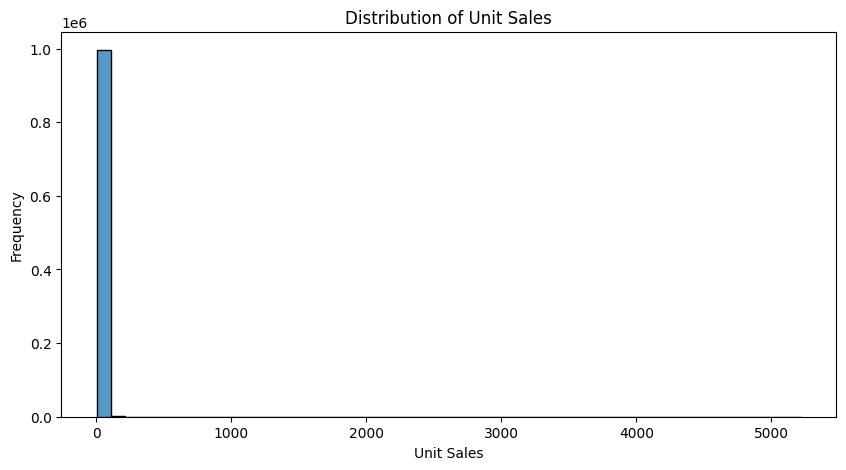

In [89]:
# 1.Target Variable Distribution

plt.figure(figsize=(10,5))

sns.histplot(master_df["unit_sales"], bins=50)

plt.title("Distribution of Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Frequency")

plt.show()

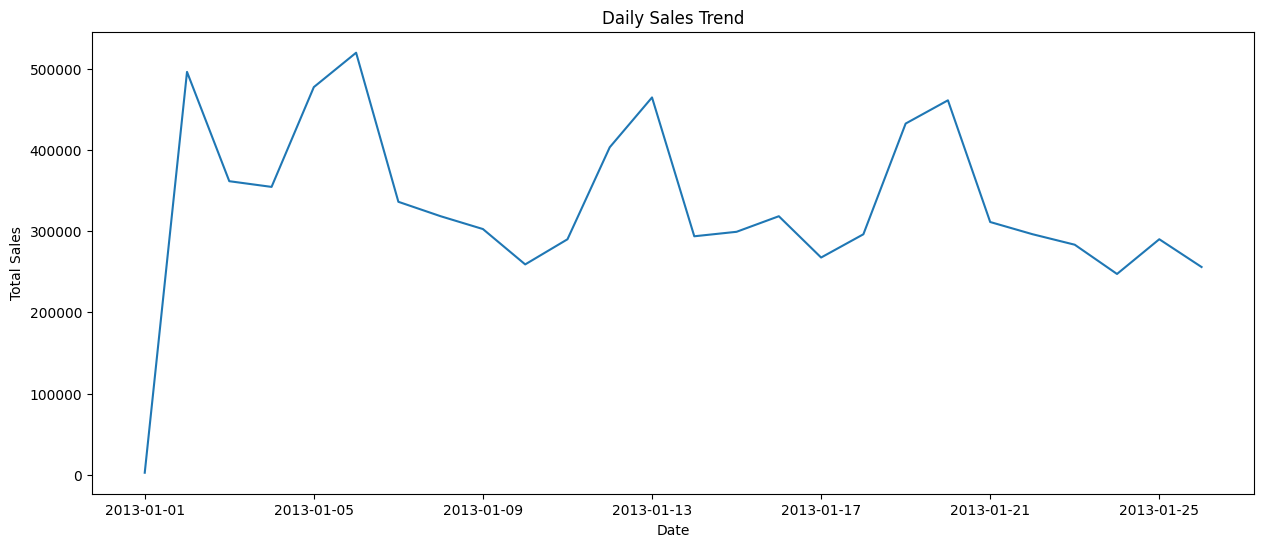

In [90]:
# 2. Daily Sales Trend

daily_sales = (
    master_df
    .groupby("date")["unit_sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["unit_sales"]
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [91]:
master_df[["onpromotion", "unit_sales"]].head()

master_df[["onpromotion", "unit_sales"]].dtypes

master_df[["onpromotion", "unit_sales"]].isnull().sum()

onpromotion    999930
unit_sales          0
dtype: int64

In [92]:
master_df["onpromotion"].dtype

dtype('float64')

In [93]:
master_df["onpromotion"] = master_df["onpromotion"].fillna(False).astype(int)

In [94]:
master_df[["onpromotion", "unit_sales"]].isnull().sum()

onpromotion    0
unit_sales     0
dtype: int64

In [95]:
master_df = master_df.dropna(subset=["unit_sales", "onpromotion"])

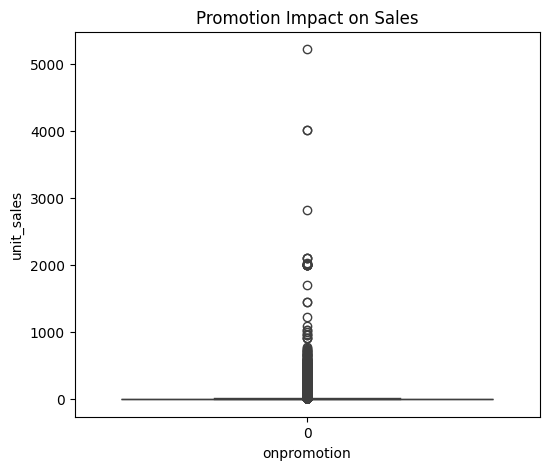

In [96]:
# 3. Promotion Impact

plt.figure(figsize=(6,5))

sns.boxplot(
    data=master_df,
    x="onpromotion",
    y="unit_sales"
)

plt.title("Promotion Impact on Sales")
plt.show()

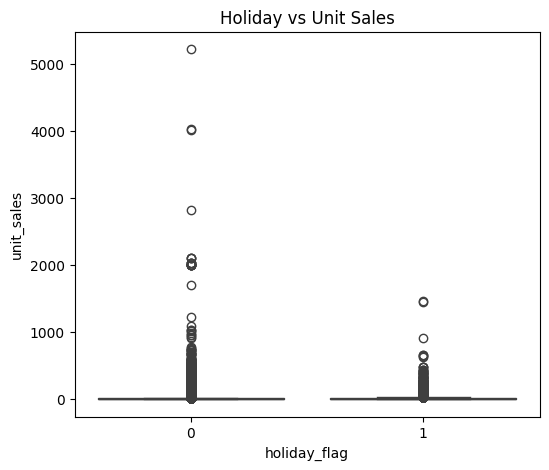

In [97]:
# 4. Holiday Impact

plt.figure(figsize=(6,5))

sns.boxplot(
    x="holiday_flag",
    y="unit_sales",
    data=master_df
)

plt.title("Holiday vs Unit Sales")

plt.show()

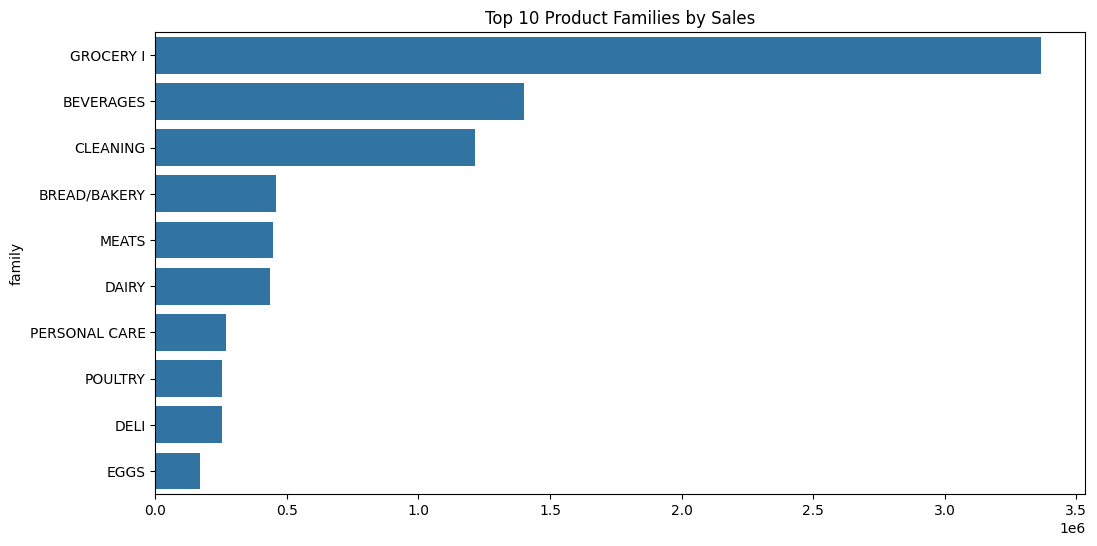

In [98]:
# 5. Sales by Product Family 

top_family = (
    master_df
    .groupby("family")["unit_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_family.values,
    y=top_family.index
)

plt.title("Top 10 Product Families by Sales")

plt.show()

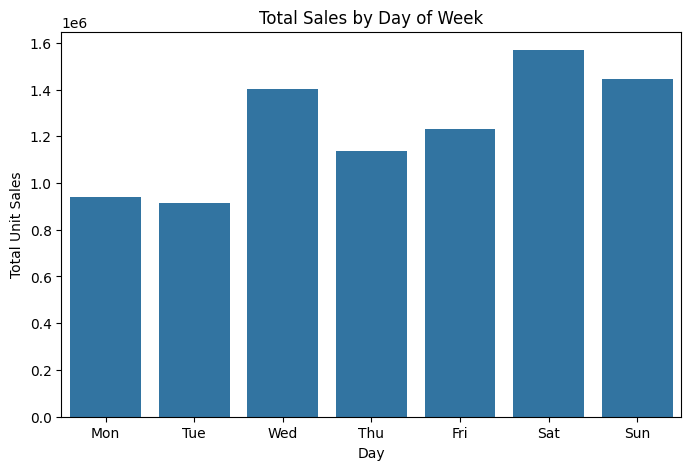

In [99]:
# 6. Sales by Day of Week

day_sales = (
    master_df.groupby("day_of_week")["unit_sales"]
             .sum()
             .reset_index()
)

day_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

day_sales["day_of_week"] = day_sales["day_of_week"].map(day_map)

plt.figure(figsize=(8,5))

sns.barplot(data=day_sales,
            x="day_of_week",
            y="unit_sales")

plt.title("Total Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Unit Sales")

plt.show()

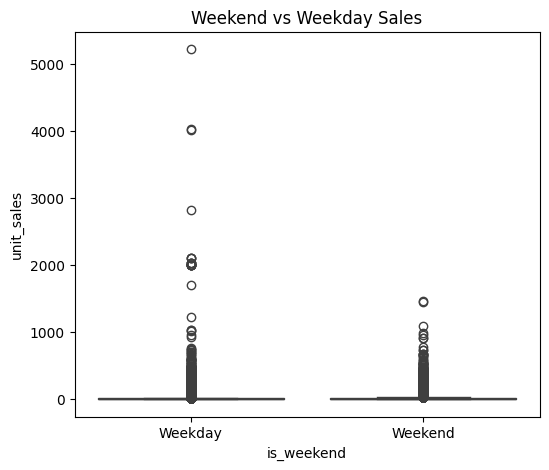

In [100]:
# 7. Weekend vs Weekday Sales

plt.figure(figsize=(6,5))

sns.boxplot(
    data=master_df,
    x="is_weekend",
    y="unit_sales"
)

plt.xticks([0,1],["Weekday","Weekend"])

plt.title("Weekend vs Weekday Sales")

plt.show()

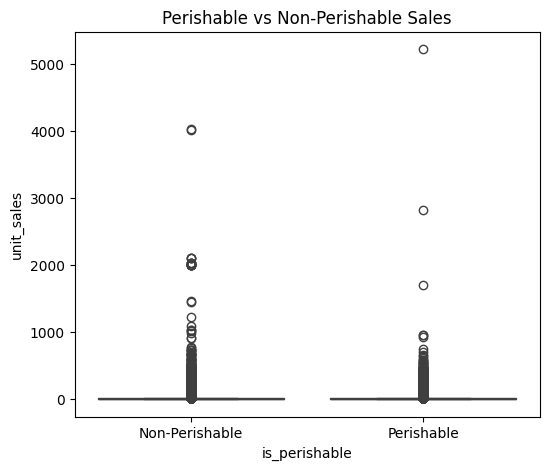

In [101]:
# 8. Perishable vs Non-Perishable Products

plt.figure(figsize=(6,5))

sns.boxplot(
    data=master_df,
    x="is_perishable",
    y="unit_sales"
)

plt.xticks([0,1],["Non-Perishable","Perishable"])

plt.title("Perishable vs Non-Perishable Sales")

plt.show()

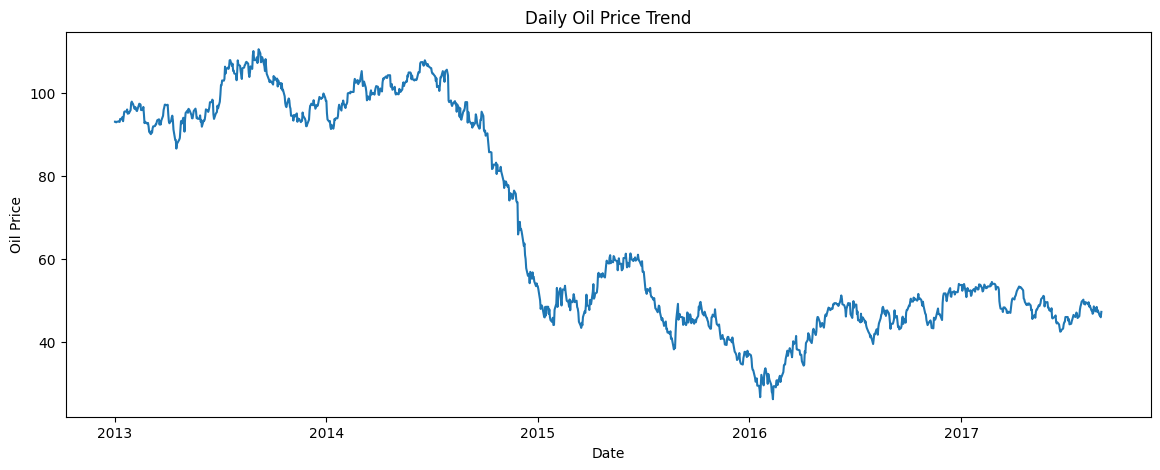

In [102]:
# 9.  Oil Price Trend

plt.figure(figsize=(14,5))

plt.plot(
    oil["date"],
    oil["oil_price"]
)

plt.title("Daily Oil Price Trend")
plt.xlabel("Date")
plt.ylabel("Oil Price")

plt.show()

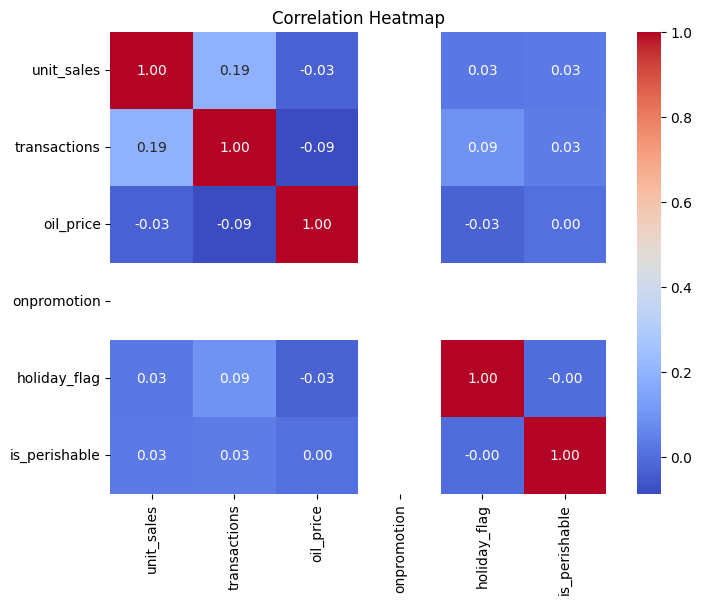

In [103]:
# 10. Correlation Heatmap

corr = master_df[
    [
        "unit_sales",
        "transactions",
        "oil_price",
        "onpromotion",
        "holiday_flag",
        "is_perishable"
    ]
].corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

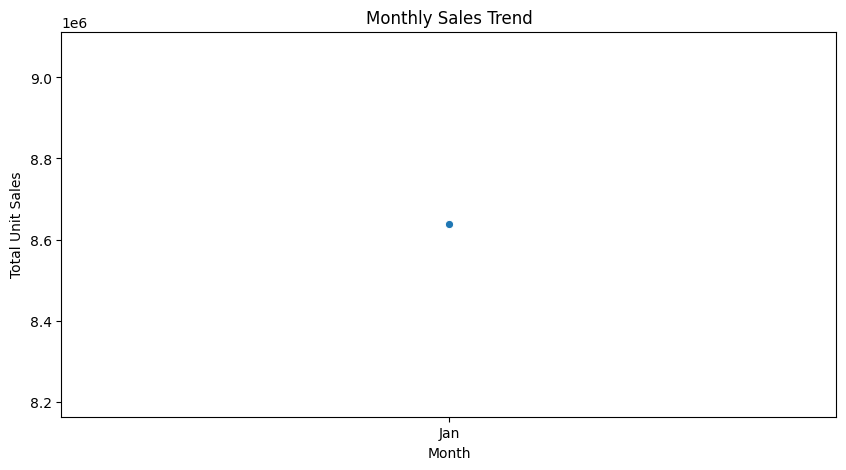

In [104]:
# 11.  Monthly Sales Trend

monthly_sales = (
    master_df.groupby("month")["unit_sales"]
             .sum()
             .reset_index()
)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_sales["month"] = monthly_sales["month"].map(month_names)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="unit_sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Unit Sales")
plt.show()

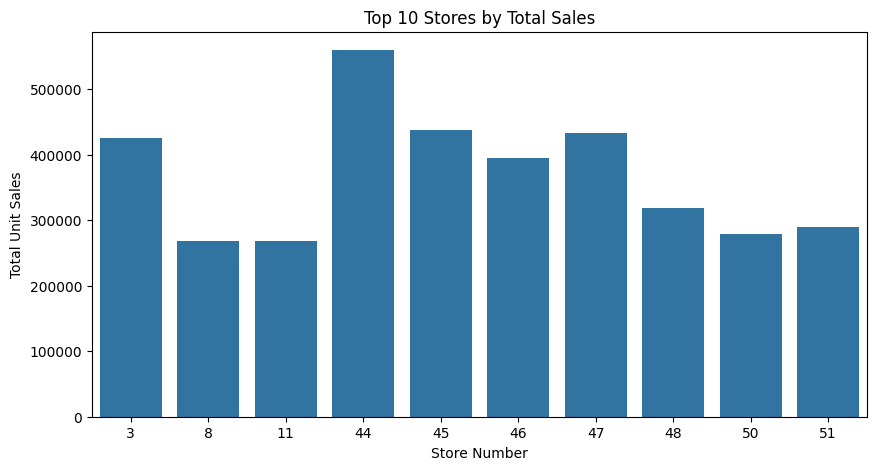

In [105]:
# 12. Top 10 Stores by Sales

top_stores = (
    master_df.groupby("store_nbr")["unit_sales"]
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_stores,
    x="store_nbr",
    y="unit_sales"
)

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Unit Sales")

plt.show()

# 8. Demand Forecasting Model

In [106]:
# 1. Select Required Features

# Select Features for ML

ml_df = master_df[
    [
        "date",
        "store_nbr",
        "item_nbr",
        "unit_sales",
        "transactions",
        "onpromotion",
        "holiday_flag",
        "oil_price",
        "is_perishable",
        "month",
        "day_of_week",
        "is_weekend"
    ]
].copy()

ml_df.head()

,date,store_nbr,item_nbr,unit_sales,transactions,onpromotion,holiday_flag,oil_price,is_perishable,month,day_of_week,is_weekend
0,2013-01-01,25,103665,7.0,770,0,1,93.14,1,1,1,0
1,2013-01-01,25,105574,1.0,770,0,1,93.14,0,1,1,0
2,2013-01-01,25,105575,2.0,770,0,1,93.14,0,1,1,0
3,2013-01-01,25,108079,1.0,770,0,1,93.14,0,1,1,0
4,2013-01-01,25,108701,1.0,770,0,1,93.14,1,1,1,0


In [107]:
# 2. Sort Dataset

ml_df = ml_df.sort_values(
    by=["item_nbr", "store_nbr", "date"]
)

In [108]:
# 3. Create Lag Feature

ml_df["lag_1"] = (
    ml_df
    .groupby(["store_nbr", "item_nbr"])["unit_sales"]
    .shift(1)
)

In [109]:
# 4. Create 7-Day Lag

ml_df["lag_7"] = (
    ml_df
    .groupby(["store_nbr", "item_nbr"])["unit_sales"]
    .shift(7)
)

In [110]:
#  5. Create Rolling Average

ml_df["rolling_mean_7"] = (
    ml_df
    .groupby(["store_nbr", "item_nbr"])["unit_sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [111]:
# 6. Remove Missing Values

ml_df.dropna(inplace=True)

ml_df.reset_index(drop=True, inplace=True)

In [112]:
ml_df.head()

,date,store_nbr,item_nbr,unit_sales,transactions,onpromotion,holiday_flag,oil_price,is_perishable,month,day_of_week,is_weekend,lag_1,lag_7,rolling_mean_7
0,2013-01-21,2,96995,1.0,1864,0,0,95.61,0,1,0,0,3.0,2.0,2.000000
1,2013-01-22,2,96995,3.0,1794,0,0,96.09,0,1,1,0,1.0,1.0,1.857143
2,2013-01-23,2,96995,1.0,1951,0,0,95.06,0,1,2,0,3.0,2.0,2.142857
3,2013-01-24,2,96995,1.0,1691,0,0,95.35,0,1,3,0,1.0,1.0,2.000000
4,2013-01-25,2,96995,1.0,1949,0,0,95.15,0,1,4,0,1.0,3.0,2.000000


In [113]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455187 entries, 0 to 455186
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            455187 non-null  datetime64[ns]
 1   store_nbr       455187 non-null  int64         
 2   item_nbr        455187 non-null  int64         
 3   unit_sales      455187 non-null  float64       
 4   transactions    455187 non-null  int64         
 5   onpromotion     455187 non-null  int64         
 6   holiday_flag    455187 non-null  int64         
 7   oil_price       455187 non-null  float64       
 8   is_perishable   455187 non-null  int64         
 9   month           455187 non-null  int32         
 10  day_of_week     455187 non-null  int32         
 11  is_weekend      455187 non-null  int64         
 12  lag_1           455187 non-null  float64       
 13  lag_7           455187 non-null  float64       
 14  rolling_mean_7  455187 non-null  flo

In [114]:
ml_df.isnull().sum()

date              0
store_nbr         0
item_nbr          0
unit_sales        0
transactions      0
onpromotion       0
holiday_flag      0
oil_price         0
is_perishable     0
month             0
day_of_week       0
is_weekend        0
lag_1             0
lag_7             0
rolling_mean_7    0
dtype: int64

# 9. Train-Test Split

In [115]:
# Define Features and Target

X = ml_df.drop(columns=["date", "unit_sales"])

y = ml_df["unit_sales"]



In [116]:
# Time-Based Train-Test Split

split_index = int(len(ml_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [117]:
# 3: Check Shapes

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (364149, 13)
Testing Features  : (91038, 13)

Training Target : (364149,)
Testing Target  : (91038,)


# 10. Train Random Forest Model

In [118]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

# 11. Prediction

In [119]:
y_pred = rf_model.predict(X_test)

# 12. Model Evaluation

In [120]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 3.91
RMSE : 14.27
R² Score : 0.3256


# 13. Feature Importance

In [121]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
12,rolling_mean_7,0.434060
11,lag_7,0.160396
1,item_nbr,0.126279
2,transactions,0.091709
10,lag_1,0.087217
5,oil_price,0.067139
0,store_nbr,0.017273
8,day_of_week,0.011484
6,is_perishable,0.004444
4,holiday_flag,0.000000


# 14. Feature Importance Plot

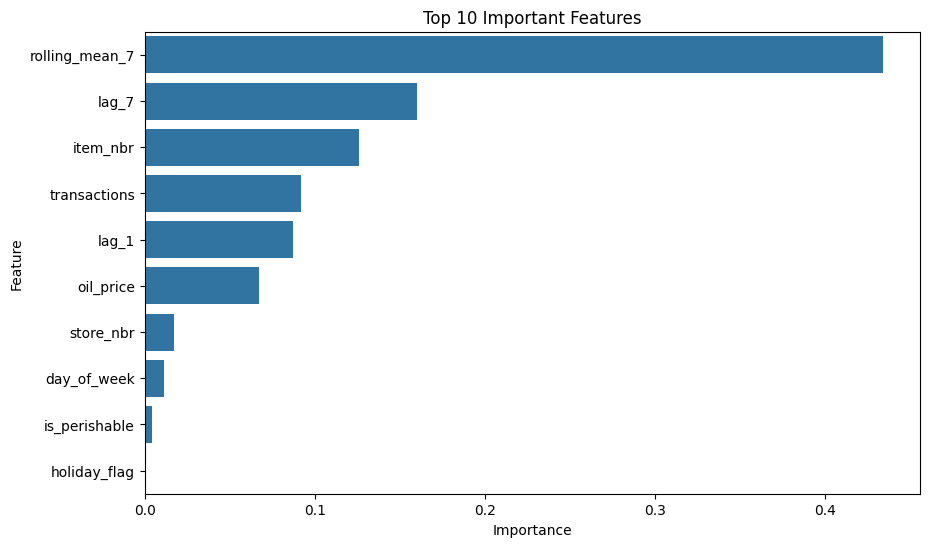

In [122]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Model Improvement 

In [149]:
ml_df = master_df.copy()

In [150]:
print(ml_df.shape)

(999930, 27)


In [151]:
#  1. Sort Dataset

ml_df = ml_df.sort_values(
    ["store_nbr", "item_nbr", "date"]
).reset_index(drop=True)

In [152]:
ml_df.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,is_perishable,city,state,type_x,cluster,transactions,oil_price,type_y,description,holiday_flag,year,month,day_of_week,is_weekend,cluster_group,sales_per_transaction,oil_price_level,family_size,avg_item_sales
0,324276,2013-01-10,1,96995,1.0,0,GROCERY I,1093,0,Quito,Pichincha,D,13,1679,93.81,NaN,NaN,0,2013,1,3,0,High,0.000596,Medium,425346,1.460317
1,362634,2013-01-11,1,96995,1.0,0,GROCERY I,1093,0,Quito,Pichincha,D,13,1813,93.60,NaN,NaN,0,2013,1,4,0,High,0.000552,Medium,425346,1.460317
2,486204,2013-01-14,1,96995,1.0,0,GROCERY I,1093,0,Quito,Pichincha,D,13,1780,94.27,NaN,NaN,0,2013,1,0,0,High,0.000562,Medium,425346,1.460317
3,644444,2013-01-18,1,96995,2.0,0,GROCERY I,1093,0,Quito,Pichincha,D,13,1745,95.61,NaN,NaN,0,2013,1,4,0,High,0.001146,High,425346,1.460317
4,770056,2013-01-21,1,96995,1.0,0,GROCERY I,1093,0,Quito,Pichincha,D,13,1770,95.61,NaN,NaN,0,2013,1,0,0,High,0.000565,High,425346,1.460317


In [153]:
#  2. Verify Missing Values

ml_df.isnull().sum().sort_values(ascending=False)

description              914647
type_y                   914647
oil_price                287086
oil_price_level          287086
unit_sales                    0
onpromotion                   0
family                        0
item_nbr                      0
id                            0
date                          0
store_nbr                     0
state                         0
city                          0
is_perishable                 0
class                         0
transactions                  0
cluster                       0
holiday_flag                  0
type_x                        0
year                          0
month                         0
is_weekend                    0
day_of_week                   0
cluster_group                 0
sales_per_transaction         0
family_size                   0
avg_item_sales                0
dtype: int64

In [163]:
print(ml_df.columns.tolist())

['id', 'date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'family', 'class', 'is_perishable', 'city', 'state', 'type_x', 'cluster', 'transactions', 'oil_price', 'holiday_flag', 'year', 'month', 'day_of_week', 'is_weekend', 'cluster_group', 'sales_per_transaction', 'family_size', 'avg_item_sales']


In [161]:
ml_df["oil_price"] = (
    ml_df["oil_price"]
    .ffill()
    .bfill()
)

In [162]:
ml_df["oil_price"].isnull().sum()

np.int64(0)

In [165]:
# 3. Feature Engineering 

group = ml_df.groupby(["store_nbr", "item_nbr"])

ml_df["lag_1"] = group["unit_sales"].shift(1)

ml_df["rolling_mean_3"] = (
    group["unit_sales"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

In [166]:
# Check Missing

ml_df[["lag_1", "rolling_mean_3"]].isnull().sum()

lag_1             53488
rolling_mean_3    53488
dtype: int64

In [167]:
ml_df = ml_df.dropna(
    subset=["lag_1", "rolling_mean_3"]
).reset_index(drop=True)

In [168]:
print(ml_df.shape)

(946442, 26)


In [170]:
# 4. Select Features

features = [
    "store_nbr",
    "item_nbr",
    "transactions",
    "oil_price",
    "onpromotion",
    "holiday_flag",
    "is_perishable",
    "month",
    "day_of_week",
    "is_weekend",
    "lag_1",
    "rolling_mean_3"
]

X = ml_df[features]

y = ml_df["unit_sales"]

In [171]:
# 5. Time-Based Split

split = int(len(ml_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(757153, 12)
(189289, 12)


In [172]:
# 6. Check Missing Values

print(X_train.isnull().sum())
print(X_test.isnull().sum())

store_nbr         0
item_nbr          0
transactions      0
oil_price         0
onpromotion       0
holiday_flag      0
is_perishable     0
month             0
day_of_week       0
is_weekend        0
lag_1             0
rolling_mean_3    0
dtype: int64
store_nbr         0
item_nbr          0
transactions      0
oil_price         0
onpromotion       0
holiday_flag      0
is_perishable     0
month             0
day_of_week       0
is_weekend        0
lag_1             0
rolling_mean_3    0
dtype: int64


In [173]:
# 7. Train Improved Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [174]:
# 8. Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 4.89
RMSE: 11.01
R²  : 0.7263


In [175]:
# 9. Feature Importance

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
11,rolling_mean_3,0.476428
10,lag_1,0.329288
1,item_nbr,0.068139
2,transactions,0.049951
0,store_nbr,0.023053
8,day_of_week,0.018958
3,oil_price,0.017725
9,is_weekend,0.010032
6,is_perishable,0.004856
5,holiday_flag,0.001569


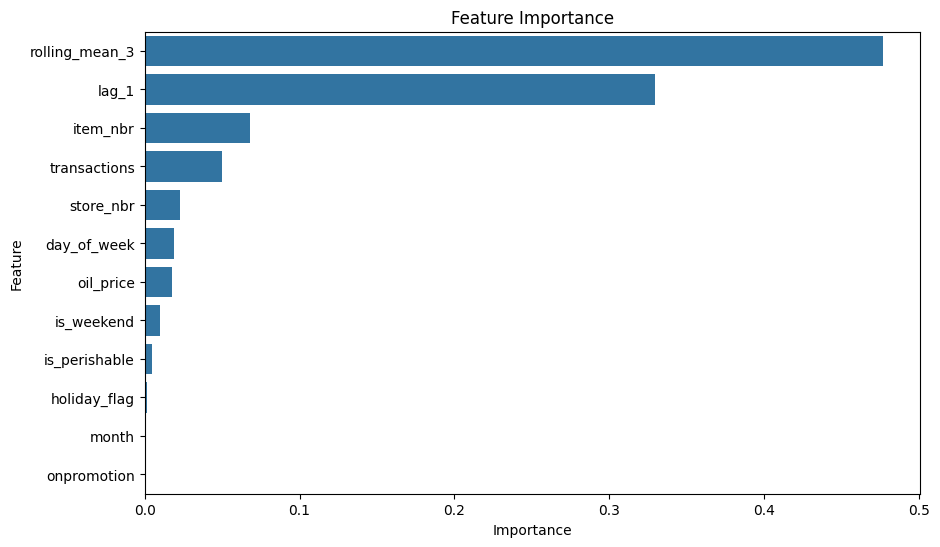

In [176]:
# 10. Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [177]:
# 11. Actual vs Predicted

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,18.0,4.316620
1,8.0,10.439498
2,7.0,10.753013
3,14.0,14.625390
4,8.0,15.394896
5,5.0,7.811706
6,7.0,8.864184
7,7.0,13.930218
8,10.0,13.002310
9,23.0,16.813087


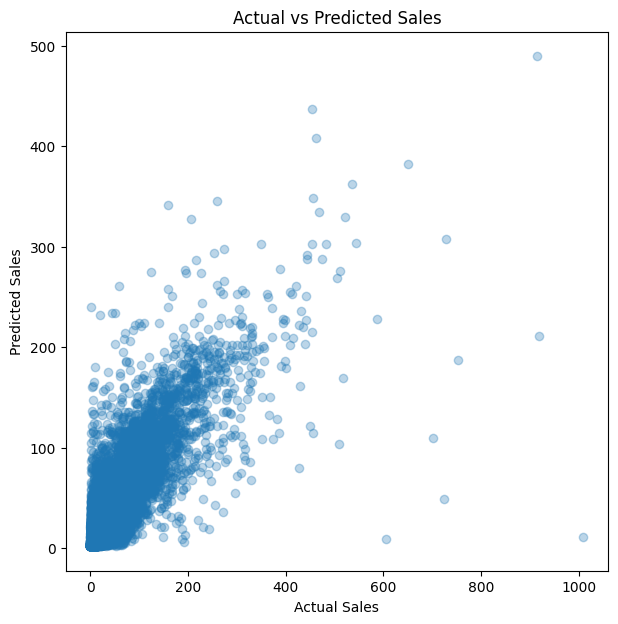

In [178]:
# 12. Scatter Plot

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

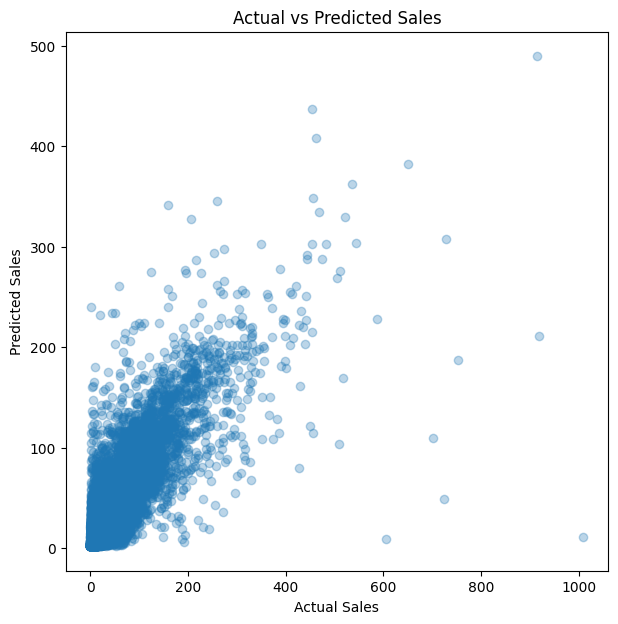

In [179]:
# 13. Scatter Plot

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()